In [29]:
# =============================================================================
# NHANES 2017-2018 | Diabetes Risk Prediction Project
# Phase 9: Machine Learning Modelling
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing and pipeline
from sklearn.model_selection import (StratifiedKFold, 
                                     cross_val_score,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (roc_auc_score, 
                              classification_report,
                              confusion_matrix,
                              roc_curve)

# SHAP
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("All packages imported successfully.")

All packages imported successfully.


In [30]:
# --- Load the dataset --------------------------------------------------------

df = pd.read_csv("nhanes_complete1_for_python.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset shape: (1394, 34)

Columns: ['diabetes', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'LBDHDD', 'LBXTR', 'LBDLDL', 'PAD680', 'ALQ121', 'ALQ151', 'HIQ011', 'RHQ131', 'RHQ160', 'RHQ162', 'SMQ040_rec', 'mean_sbp', 'mean_dbp', 'SEQN', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'LBXGH', 'LBXGLU', 'DIQ010_clean', 'diabetes_f', 'race_f', 'educ_f', 'insurance_f', 'gdm_f', 'smoking_f', 'bmi_cat']

Missing values per column:
LBXGH            80
LBXGLU          771
DIQ010_clean      1
dtype: int64


In [31]:
# --- Define features and outcome — CORRECTED ---------------------------------

# Full list of columns to exclude from the feature matrix
drop_cols = [
    # Outcome variable
    "diabetes",

    # Outcome source variables — defined the outcome, cannot be predictors
    "LBXGH",           # HbA1c
    "LBXGLU",          # Fasting glucose
    "DIQ010_clean",    # Self-reported diabetes

    # Survey design variables — not predictors
    "SEQN",
    "WTMEC2YR",
    "SDMVSTRA",
    "SDMVPSU",

    # Labelled factor variables created in Phase 7 for visualisation
    # These are string versions of variables already in X as numbers
    # Keeping both would be duplicate information — keep the numeric versions
    "diabetes_f",
    "race_f",
    "educ_f",
    "insurance_f",
    "gdm_f",
    "smoking_f",
    "bmi_cat"
]

# Feature matrix and outcome
X = df.drop(columns=drop_cols)
y = df["diabetes"]

# Survey weights
weights = df["WTMEC2YR"]

print(f"Feature matrix shape: {X.shape}")
print(f"\nOutcome distribution:")
print(y.value_counts())
print(f"\nClass balance:")
print(y.value_counts(normalize=True).round(3))
print(f"\nFeature names:")
print(list(X.columns))
print(f"\nData types:")
print(X.dtypes)

Feature matrix shape: (1394, 19)

Outcome distribution:
diabetes
0    1298
1      96
Name: count, dtype: int64

Class balance:
diabetes
0    0.931
1    0.069
Name: proportion, dtype: float64

Feature names:
['RIDAGEYR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'LBDHDD', 'LBXTR', 'LBDLDL', 'PAD680', 'ALQ121', 'ALQ151', 'HIQ011', 'RHQ131', 'RHQ160', 'RHQ162', 'SMQ040_rec', 'mean_sbp', 'mean_dbp']

Data types:
RIDAGEYR        int64
RIDRETH3        int64
DMDEDUC2        int64
INDFMPIR      float64
BMXBMI        float64
BMXWAIST      float64
LBDHDD          int64
LBXTR           int64
LBDLDL          int64
PAD680          int64
ALQ121          int64
ALQ151          int64
HIQ011          int64
RHQ131          int64
RHQ160          int64
RHQ162          int64
SMQ040_rec      int64
mean_sbp      float64
mean_dbp      float64
dtype: object


In [32]:
# --- Drop the one row with missing diabetes outcome --------------------------

# From Phase 3 we know 1 participant has missing diabetes status
# This row cannot be used for supervised learning — drop it

missing_outcome = y.isnull()
print(f"Rows with missing outcome: {missing_outcome.sum()}")

X       = X[~missing_outcome]
y       = y[~missing_outcome]
weights = weights[~missing_outcome]

# Reset index after dropping
X       = X.reset_index(drop=True)
y       = y.reset_index(drop=True)
weights = weights.reset_index(drop=True)

print(f"Shape after dropping missing outcome: {X.shape}")

Rows with missing outcome: 0
Shape after dropping missing outcome: (1394, 19)


In [33]:
# --- Stratified train/test split ---------------------------------------------

# 80% training, 20% test
# stratify=y ensures the 6.9% diabetic proportion is preserved
# in both the training and test sets

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size    = 0.20,
    random_state = SEED,
    stratify     = y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nTraining outcome distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest outcome distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 1115 rows
Test set:     279 rows

Training outcome distribution:
diabetes
0    0.931
1    0.069
Name: proportion, dtype: float64

Test outcome distribution:
diabetes
0    0.932
1    0.068
Name: proportion, dtype: float64


In [34]:
# --- Define the cross-validation strategy ------------------------------------

# StratifiedKFold preserves the 6.9% diabetic proportion in each fold
# 5 folds is standard — each fold uses 80% for training, 20% for validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("5-fold stratified cross-validation defined.")

5-fold stratified cross-validation defined.


In [35]:
# --- Define the four model pipelines -----------------------------------------

# Each pipeline has three steps:
# Step 1: SimpleImputer — fills any residual NAs with column median
# Step 2: StandardScaler — standardises all features to mean=0, SD=1
# Step 3: The classifier

# Note: SMOTE is added inside the ImbPipeline so it only runs on
# training folds during cross-validation, never on validation folds

# --- Model 1: Logistic Regression (survey-weighted ML baseline) --------------
pipe_lr = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=SEED, k_neighbors=5)),
    ("model",   LogisticRegression(
                    max_iter     = 1000,
                    random_state = SEED,
                    class_weight = None   # SMOTE handles imbalance
                ))
])

In [36]:
# --- Model 2: Random Forest --------------------------------------------------
pipe_rf = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=SEED, k_neighbors=5)),
    ("model",   RandomForestClassifier(
                    n_estimators = 500,    # Number of trees
                    max_depth    = None,   # Trees grow until pure leaves
                    min_samples_leaf = 5,  # Minimum 5 samples per leaf
                    class_weight = None,   # SMOTE handles imbalance
                    random_state = SEED,
                    n_jobs       = -1      # Use all CPU cores
                ))
])

In [37]:
# --- Model 3: XGBoost --------------------------------------------------------
pipe_xgb = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=SEED, k_neighbors=5)),
    ("model",   XGBClassifier(
                    n_estimators      = 300,
                    learning_rate     = 0.05,
                    max_depth         = 4,
                    subsample         = 0.8,
                    colsample_bytree  = 0.8,
                    use_label_encoder = False,
                    eval_metric       = "auc",
                    random_state      = SEED,
                    n_jobs            = -1
                ))
])

In [38]:
# --- Model 4: LightGBM -------------------------------------------------------
pipe_lgbm = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=SEED, k_neighbors=5)),
    ("model",   LGBMClassifier(
                    n_estimators    = 300,
                    learning_rate   = 0.05,
                    max_depth       = 4,
                    subsample       = 0.8,
                    colsample_bytree= 0.8,
                    random_state    = SEED,
                    n_jobs          = -1,
                    verbose         = -1    # Suppress training output
                ))
])

print("All four model pipelines defined.")

All four model pipelines defined.


In [39]:
# --- Run 5-fold cross-validation for all four models ------------------------

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest":       pipe_rf,
    "XGBoost":             pipe_xgb,
    "LightGBM":            pipe_lgbm
}

cv_results = {}

for name, pipeline in models.items():
    print(f"Running CV for: {name}...")

    scores = cross_val_score(
        estimator = pipeline,
        X         = X_train,
        y         = y_train,
        cv        = cv,
        scoring   = "roc_auc",
        n_jobs    = -1
    )

    cv_results[name] = scores

    print(f"  AUC scores per fold: {scores.round(3)}")
    print(f"  Mean AUC: {scores.mean():.3f} ± {scores.std():.3f}\n")

print("Cross-validation complete.")

Running CV for: Logistic Regression...
  AUC scores per fold: [0.781 0.861 0.896 0.927 0.96 ]
  Mean AUC: 0.885 ± 0.061

Running CV for: Random Forest...
  AUC scores per fold: [0.742 0.898 0.858 0.902 0.963]
  Mean AUC: 0.872 ± 0.073

Running CV for: XGBoost...
  AUC scores per fold: [0.723 0.843 0.844 0.899 0.958]
  Mean AUC: 0.853 ± 0.078

Running CV for: LightGBM...
  AUC scores per fold: [0.713 0.815 0.805 0.894 0.94 ]
  Mean AUC: 0.834 ± 0.078

Cross-validation complete.


In [40]:
# --- Build model comparison table --------------------------------------------

comparison_df = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "Mean_AUC": [scores.mean() for scores in cv_results.values()],
    "SD_AUC":   [scores.std()  for scores in cv_results.values()],
    "AUC_per_fold": [list(scores.round(3)) for scores in cv_results.values()]
}).sort_values("Mean_AUC", ascending=False).reset_index(drop=True)

comparison_df["AUC_display"] = (
    comparison_df["Mean_AUC"].round(3).astype(str) + " ± " +
    comparison_df["SD_AUC"].round(3).astype(str)
)

print("Model comparison:\n")
print(comparison_df[["Model", "AUC_display"]].to_string(index=False))

# Save for Power BI
comparison_df[["Model", "Mean_AUC", "SD_AUC"]].to_csv(
    "model_comparison.csv", index=False
)
print("\nSaved: model_comparison.csv")

Model comparison:

              Model   AUC_display
Logistic Regression 0.885 ± 0.061
      Random Forest 0.872 ± 0.073
            XGBoost 0.853 ± 0.078
           LightGBM 0.834 ± 0.078

Saved: model_comparison.csv


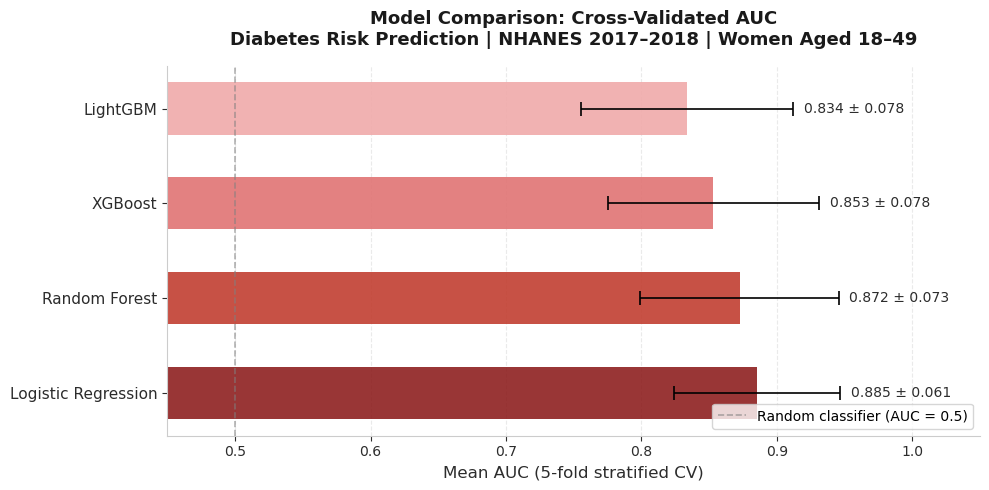

Saved: model_comparison.png


In [41]:
# --- Plot model comparison — Clinical warm palette ---------------------------

# Palette chosen to reflect the medical/health theme of the project
# Deep burgundy for best model, gradient of muted reds/rose for others
# Clean white background for professional portfolio presentation

clinical_palette = ["#8B1A1A",   # Deep burgundy — best model
                    "#C0392B",   # Strong red
                    "#E07070",   # Muted rose
                    "#F0A8A8"]   # Soft blush — weakest model

fig, ax = plt.subplots(figsize=(10, 5))

# Horizontal bars — models sorted best to worst (comparison_df already sorted)
bars = ax.barh(
    comparison_df["Model"],
    comparison_df["Mean_AUC"],
    xerr    = comparison_df["SD_AUC"],
    color   = clinical_palette,   # American spelling — no 'u'
    alpha   = 0.88,
    capsize = 5,
    height  = 0.55,
    error_kw = dict(ecolor="black", elinewidth=1.2, capthick=1.2)
)

# Reference line at AUC = 0.5 (random classifier)
ax.axvline(
    x         = 0.5,
    linestyle = "--",
    color     = "grey",       # American spelling
    alpha     = 0.6,
    linewidth = 1.2,
    label     = "Random classifier (AUC = 0.5)"
)

# AUC value labels on each bar
for i, (auc, sd) in enumerate(zip(comparison_df["Mean_AUC"],
                                   comparison_df["SD_AUC"])):
    ax.text(
        auc + sd + 0.008,    # Position just after the error bar
        i,                   # Height matches bar position
        f"{auc:.3f} ± {sd:.3f}",
        va       = "center",
        fontsize = 10,
        color    = "#2C2C2C"  # Near-black for readability
    )

# Formatting
ax.set_xlabel("Mean AUC (5-fold stratified CV)", fontsize=12,
              color="#2C2C2C")
ax.set_xlim(0.45, 1.05)
ax.set_title(
    "Model Comparison: Cross-Validated AUC\n"
    "Diabetes Risk Prediction | NHANES 2017–2018 | Women Aged 18–49",
    fontsize = 13,
    fontweight = "bold",
    color    = "#1A1A1A",
    pad      = 15
)
ax.set_yticklabels(comparison_df["Model"], fontsize=11)
ax.legend(fontsize=10, loc="lower right")

# Remove top and right spines for clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#2C2C2C")

# Subtle horizontal gridlines
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: model_comparison.png")

In [42]:
# --- Fit all models on full training set ------------------------------------
# Cross-validation tells us performance. Now we train on the full
# training set to get the final models for Phase 10 evaluation.

print("Fitting final models on full training set...\n")

fitted_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    print(f"  {name} — fitted.")

print("\nAll models fitted on full training set.")

Fitting final models on full training set...

  Logistic Regression — fitted.
  Random Forest — fitted.
  XGBoost — fitted.
  LightGBM — fitted.

All models fitted on full training set.


In [43]:
# --- Save fitted models ------------------------------------------------------

import pickle

for name, model in fitted_models.items():
    filename = name.lower().replace(" ", "_") + "_model.pkl"
    with open(filename, "wb") as f:
        pickle.dump(model, f)
    print(f"  Saved: {filename}")

# Save test set for Phase 10
X_test.to_csv("X_test.csv",   index=False)
y_test.to_csv("y_test.csv",   index=False)
w_test.to_csv("w_test.csv",   index=False)
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)

print("\nTest and training sets saved.")
print("\nPhase 9 complete. Ready for Phase 10.")

  Saved: logistic_regression_model.pkl
  Saved: random_forest_model.pkl
  Saved: xgboost_model.pkl
  Saved: lightgbm_model.pkl

Test and training sets saved.

Phase 9 complete. Ready for Phase 10.


In [44]:
# =============================================================================
# Phase 10: Model Evaluation, Calibration, and SHAP Analysis
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (roc_auc_score, roc_curve,
                              confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
import shap

SEED = 42
np.random.seed(SEED)

print("All imports successful.")

All imports successful.


In [45]:
# --- Load test data ----------------------------------------------------------

X_test  = pd.read_csv("X_test.csv")
y_test  = pd.read_csv("y_test.csv").squeeze()
w_test  = pd.read_csv("w_test.csv").squeeze()
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()

# --- Load all four fitted models ---------------------------------------------

model_names = ["logistic_regression", "random_forest",
               "xgboost", "lightgbm"]
fitted_models = {}

for name in model_names:
    with open(f"{name}_model.pkl", "rb") as f:
        fitted_models[name] = pickle.load(f)
    print(f"Loaded: {name}")

display_names = {
    "logistic_regression": "Logistic Regression",
    "random_forest":       "Random Forest",
    "xgboost":             "XGBoost",
    "lightgbm":            "LightGBM"
}

print(f"\nTest set shape: {X_test.shape}")
print(f"Test outcome distribution:\n{y_test.value_counts()}")

Loaded: logistic_regression
Loaded: random_forest
Loaded: xgboost
Loaded: lightgbm

Test set shape: (279, 19)
Test outcome distribution:
diabetes
0    260
1     19
Name: count, dtype: int64


In [46]:
# --- Generate predictions for all models ------------------------------------

probas = {}
preds  = {}

for name, model in fitted_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    probas[name] = prob
    preds[name]  = pred
    auc = roc_auc_score(y_test, prob)
    print(f"{display_names[name]:25s} | Test AUC: {auc:.3f}")

Logistic Regression       | Test AUC: 0.861
Random Forest             | Test AUC: 0.889
XGBoost                   | Test AUC: 0.846
LightGBM                  | Test AUC: 0.811


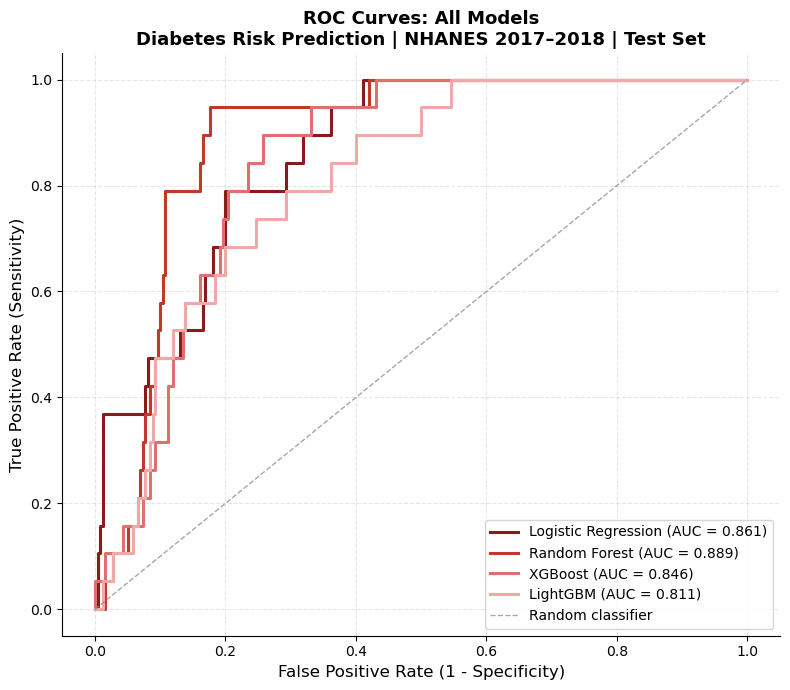

Saved: roc_curves.png


In [47]:
# --- ROC curves — all four models -------------------------------------------

roc_colors = {
    "logistic_regression": "#8B1A1A",
    "random_forest":       "#C0392B",
    "xgboost":             "#E07070",
    "lightgbm":            "#F0A8A8"
}

fig, ax = plt.subplots(figsize=(8, 7))

for name in fitted_models:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    auc          = roc_auc_score(y_test, probas[name])
    ax.plot(fpr, tpr, color=roc_colors[name], linewidth=2.2,
            label=f"{display_names[name]} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey",
        linewidth=1, alpha=0.7, label="Random classifier")

ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)",      fontsize=12)
ax.set_title("ROC Curves: All Models\n"
             "Diabetes Risk Prediction | NHANES 2017–2018 | Test Set",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: roc_curves.png")

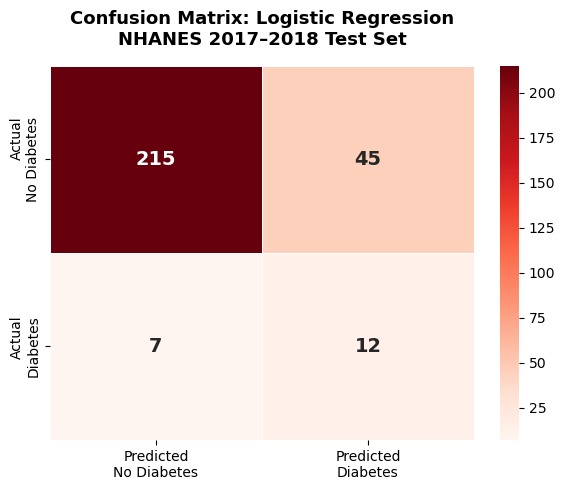

Saved: confusion_matrix.png


In [48]:
# --- Confusion matrix — best model (Logistic Regression) --------------------

best_model_name = "logistic_regression"
best_pred       = preds[best_model_name]
best_prob       = probas[best_model_name]

cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            linewidths=0.5, linecolor="white", ax=ax,
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=["Predicted\nNo Diabetes", "Predicted\nDiabetes"],
            yticklabels=["Actual\nNo Diabetes",    "Actual\nDiabetes"])

ax.set_title("Confusion Matrix: Logistic Regression\n"
             "NHANES 2017–2018 Test Set",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: confusion_matrix.png")

In [49]:
# --- Performance metrics -----------------------------------------------------

tn, fp, fn, tp = confusion_matrix(y_test, best_pred).ravel()

metrics_df = pd.DataFrame({
    "Metric": ["AUC", "Sensitivity (Recall)", "Specificity",
               "PPV (Precision)", "NPV", "Accuracy", "Brier Score"],
    "Value":  [round(roc_auc_score(y_test, best_prob), 3),
               round(tp / (tp + fn), 3),
               round(tn / (tn + fp), 3),
               round(tp / (tp + fp), 3),
               round(tn / (tn + fn), 3),
               round((tp + tn) / (tp + tn + fp + fn), 3),
               round(brier_score_loss(y_test, best_prob), 3)]
})

print("Performance metrics — Logistic Regression (Test Set):\n")
print(metrics_df.to_string(index=False))

metrics_df.to_csv("performance_metrics.csv", index=False)
print("\nSaved: performance_metrics.csv")

Performance metrics — Logistic Regression (Test Set):

              Metric  Value
                 AUC  0.861
Sensitivity (Recall)  0.632
         Specificity  0.827
     PPV (Precision)  0.211
                 NPV  0.968
            Accuracy  0.814
         Brier Score  0.141

Saved: performance_metrics.csv


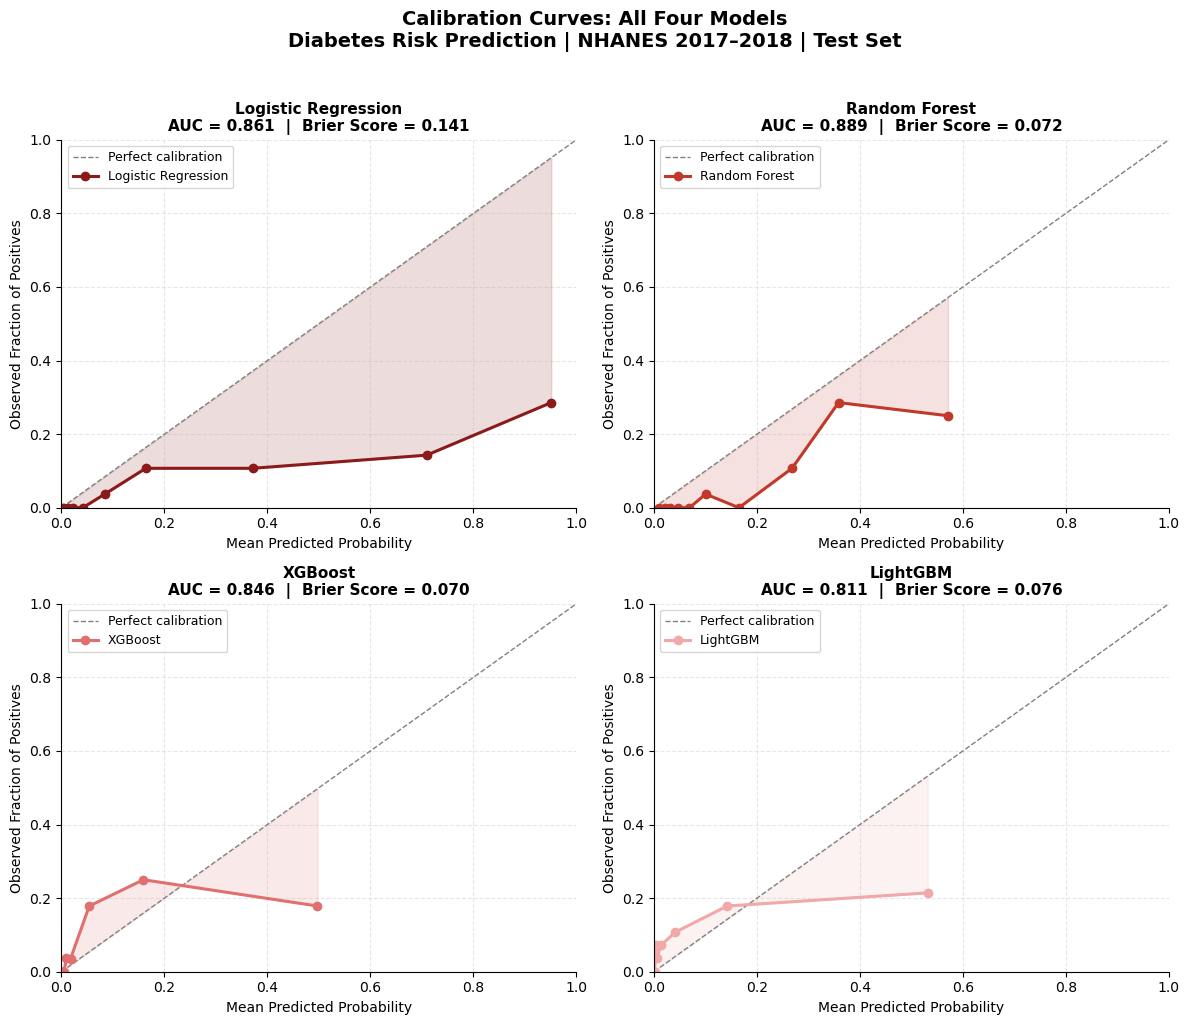

Saved: calibration_curves_all_models.png


In [59]:
# --- Calibration curves — all 4 models --------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

model_order = ["logistic_regression", "random_forest",
               "xgboost", "lightgbm"]

for idx, name in enumerate(model_order):

    fraction_pos, mean_pred = calibration_curve(
        y_test,
        probas[name],
        n_bins   = 10,
        strategy = "quantile"
    )

    ax = axes[idx]

    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1],
            linestyle = "--",
            color     = "grey",
            linewidth = 1,
            label     = "Perfect calibration")

    # Model calibration curve
    ax.plot(mean_pred, fraction_pos,
            color     = roc_colors[name],
            linewidth = 2.2,
            marker    = "o",
            markersize= 6,
            label     = display_names[name])

    # Shade the gap between model and perfect calibration
    ax.fill_between(mean_pred, fraction_pos, mean_pred,
                    alpha = 0.15,
                    color = roc_colors[name])

    # Brier score for this model
    brier = brier_score_loss(y_test, probas[name])
    auc   = roc_auc_score(y_test, probas[name])

    ax.set_title(f"{display_names[name]}\n"
                 f"AUC = {auc:.3f}  |  Brier Score = {brier:.3f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean Predicted Probability", fontsize=10)
    ax.set_ylabel("Observed Fraction of Positives", fontsize=10)
    ax.legend(fontsize=9, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle(
    "Calibration Curves: All Four Models\n"
    "Diabetes Risk Prediction | NHANES 2017–2018 | Test Set",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("calibration_curves_all_models.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: calibration_curves_all_models.png")

In [58]:
# --- Brier scores comparison table ------------------------------------------

brier_scores = pd.DataFrame({
    "Model":       list(display_names.values()),
    "Test_AUC":    [round(roc_auc_score(y_test, probas[n]), 3)
                    for n in fitted_models],
    "Brier_Score": [round(brier_score_loss(y_test, probas[n]), 3)
                    for n in fitted_models]
}).sort_values("Brier_Score")

print("Model calibration comparison (lower Brier = better calibrated):\n")
print(brier_scores.to_string(index=False))

brier_scores.to_csv("calibration_comparison.csv", index=False)
print("\nSaved: calibration_comparison.csv")

Model calibration comparison (lower Brier = better calibrated):

              Model  Test_AUC  Brier_Score
            XGBoost     0.846        0.070
      Random Forest     0.889        0.072
           LightGBM     0.811        0.076
Logistic Regression     0.861        0.141

Saved: calibration_comparison.csv


In [51]:
# --- Prepare data for SHAP ---------------------------------------------------
# This cell builds everything SHAP needs from scratch
# so it does not depend on any previous session variables

# Step 1: Extract pipeline components by name
imputer    = fitted_models[best_model_name].named_steps["imputer"]
scaler     = fitted_models[best_model_name].named_steps["scaler"]
classifier = fitted_models[best_model_name].named_steps["model"]

# Step 2: Apply imputer then scaler to test data
X_test_imputed    = imputer.transform(X_test)
X_test_scaled     = scaler.transform(X_test_imputed)

# Step 3: Wrap scaled data in DataFrame (for SHAP explainer)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns = X_test.columns
)

# Step 4: Wrap imputed (unscaled) data in DataFrame
#         This is what we display on x-axes — real original values
X_test_imputed_df = pd.DataFrame(
    X_test_imputed,
    columns = X_test.columns
)

# Step 5: Define readable feature labels
feature_labels = {
    "RIDAGEYR"   : "Age (years)",
    "LBXTR"      : "Triglycerides (mg/dL)",
    "RHQ162"     : "Age at first pregnancy",
    "DMDEDUC2"   : "Education level",
    "SMQ040_rec" : "Smoking status",
    "LBDLDL"     : "LDL cholesterol (mg/dL)",
    "HIQ011"     : "Health insurance",
    "LBDHDD"     : "HDL cholesterol (mg/dL)",
    "ALQ121"     : "Alcohol use frequency",
    "RHQ131"     : "Gestational diabetes history",
    "BMXBMI"     : "BMI (kg/m²)",
    "BMXWAIST"   : "Waist circumference (cm)",
    "RHQ160"     : "Number of pregnancies",
    "RIDRETH3"   : "Race/ethnicity",
    "INDFMPIR"   : "Income-to-poverty ratio",
    "PAD680"     : "Sedentary minutes/day",
    "mean_sbp"   : "Mean systolic BP (mmHg)",
    "mean_dbp"   : "Mean diastolic BP (mmHg)",
    "ALQ151"     : "Heavy alcohol use"
}

# Step 6: Create labelled DataFrames for display
X_test_scaled_labelled  = X_test_scaled_df.rename(columns=feature_labels)
X_test_original_labelled = X_test_imputed_df.rename(columns=feature_labels)

# Step 7: Compute SHAP values on scaled data
#         (correct because model was trained on scaled data)
explainer   = shap.LinearExplainer(classifier, X_test_scaled_labelled)
shap_values = explainer.shap_values(X_test_scaled_labelled)

print(f"SHAP values computed successfully.")
print(f"Shape: {shap_values.shape}")
print(f"\nSample of original-scale values:")
print(X_test_original_labelled[
    ["Age (years)", "Triglycerides (mg/dL)", "BMI (kg/m²)"]
].describe().round(1))

SHAP values computed successfully.
Shape: (279, 19)

Sample of original-scale values:
       Age (years)  Triglycerides (mg/dL)  BMI (kg/m²)
count        279.0                  279.0        279.0
mean          32.5                   90.0         29.7
std            9.2                   69.4          8.6
min           18.0                   10.0         16.3
25%           24.0                   49.5         22.7
50%           33.0                   70.0         28.5
75%           40.0                  106.0         34.2
max           49.0                  644.0         59.1


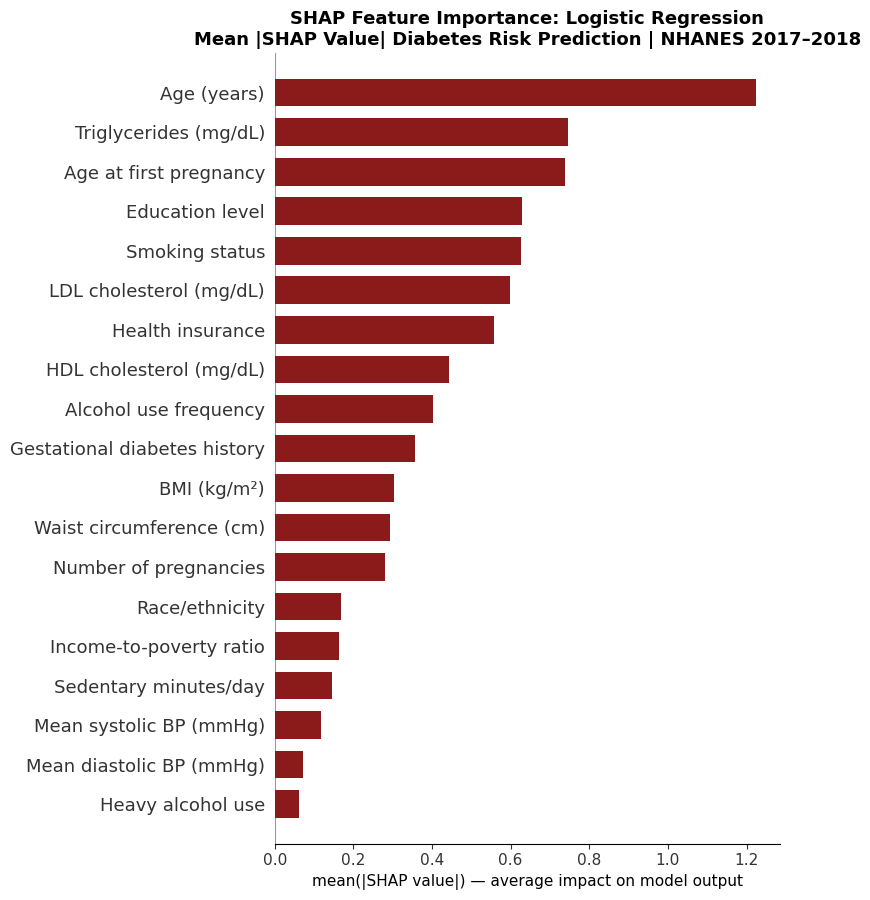

Saved: shap_importance_bar_final.png


In [52]:
# --- SHAP importance bar plot ------------------------------------------------

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_original_labelled,
    plot_type   = "bar",
    color       = "#8B1A1A",
    max_display = 19,
    show        = False
)

plt.title("SHAP Feature Importance: Logistic Regression\n"
          "Mean |SHAP Value| Diabetes Risk Prediction | NHANES 2017–2018",
          fontsize=13, fontweight="bold")
plt.xlabel("mean(|SHAP value|) — average impact on model output",
           fontsize=11)
plt.tight_layout()
plt.savefig("shap_importance_bar_final.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: shap_importance_bar_final.png")

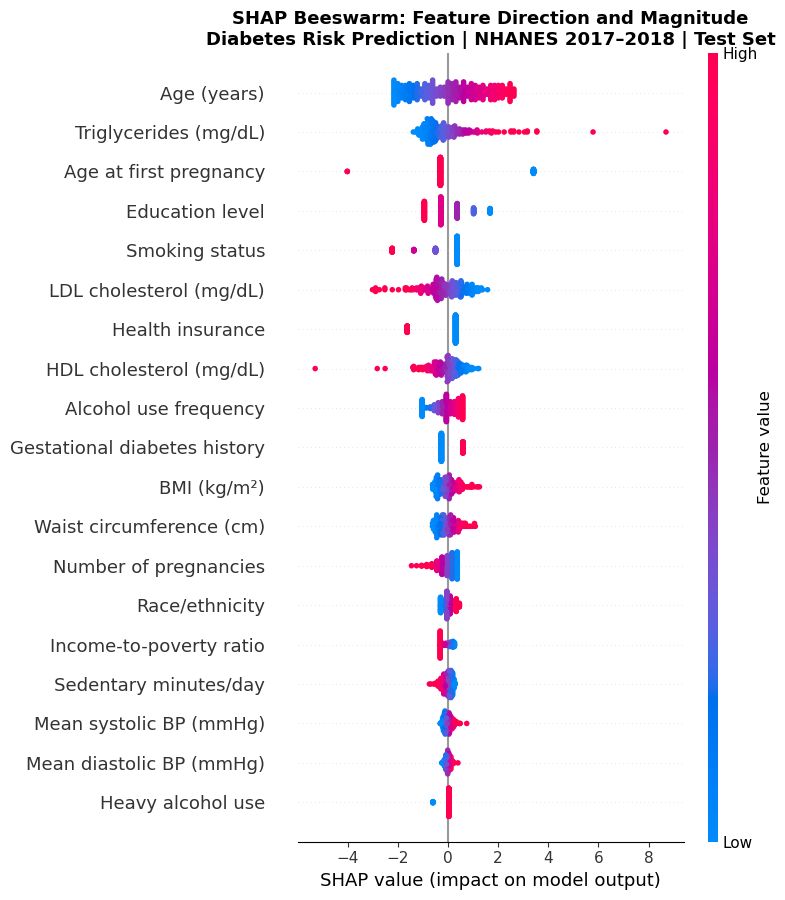

Saved: shap_beeswarm_final.png


In [53]:
# --- SHAP beeswarm plot ------------------------------------------------------

plt.figure(figsize=(11, 8))

shap.summary_plot(
    shap_values,
    X_test_original_labelled,
    plot_type   = "dot",
    max_display = 19,
    show        = False
)

plt.title("SHAP Beeswarm: Feature Direction and Magnitude\n"
          "Diabetes Risk Prediction | NHANES 2017–2018 | Test Set",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm_final.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: shap_beeswarm_final.png")

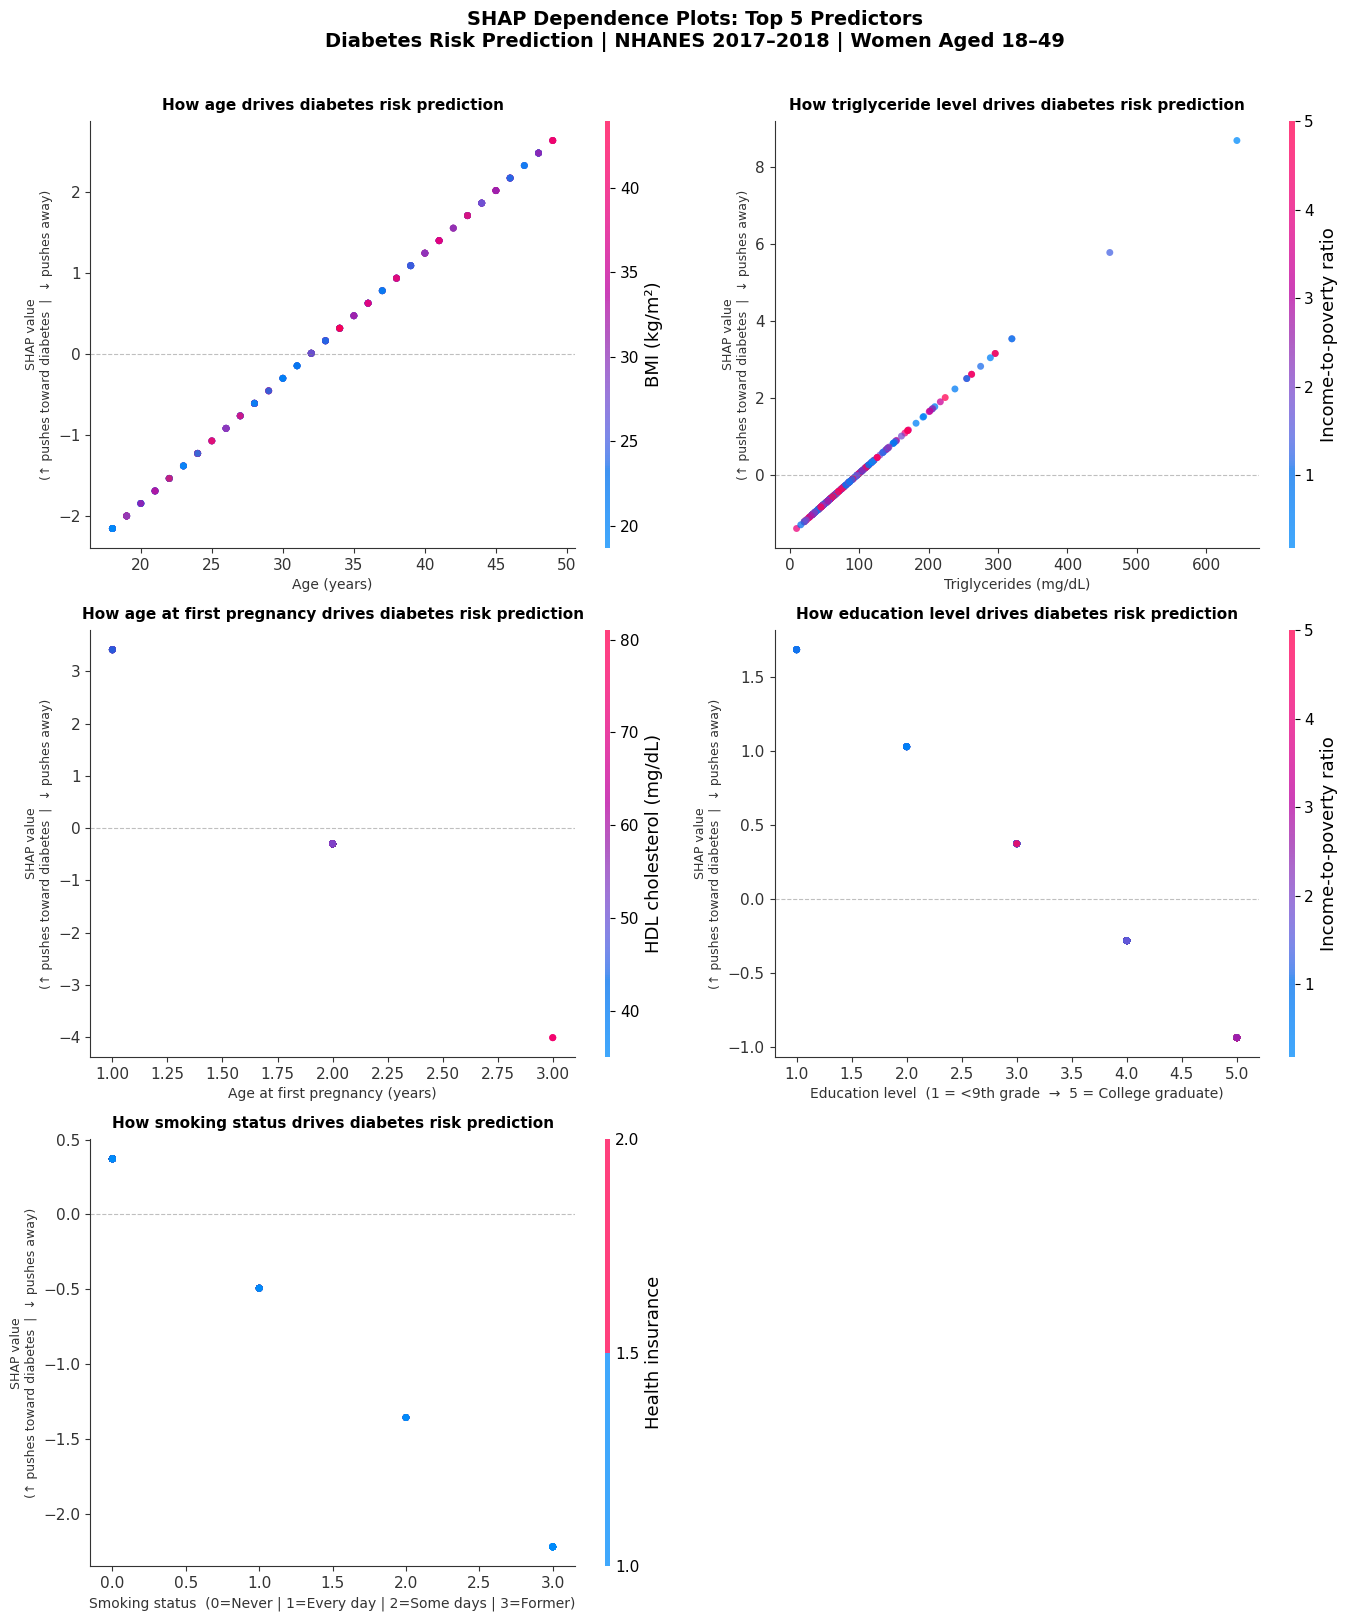

Saved: shap_dependence_top5_final.png


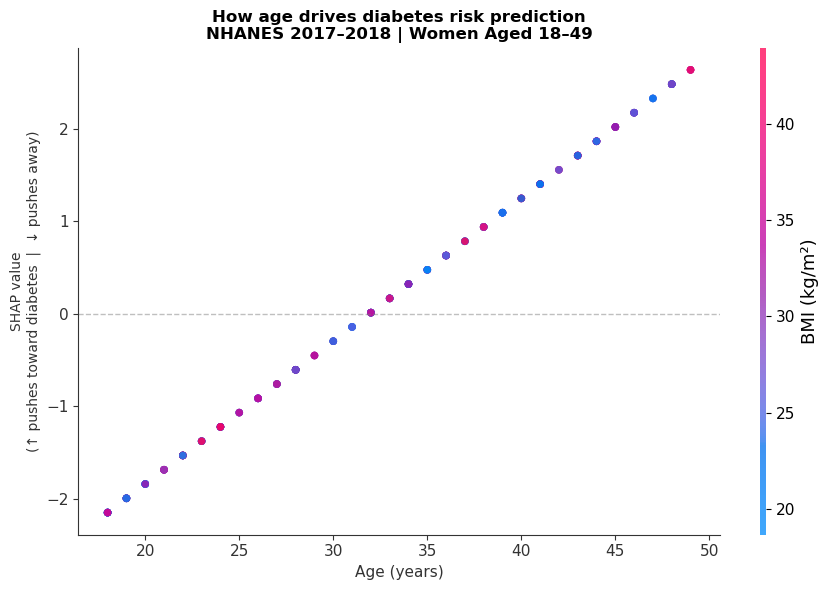

Saved: shap_dep_age_years.png


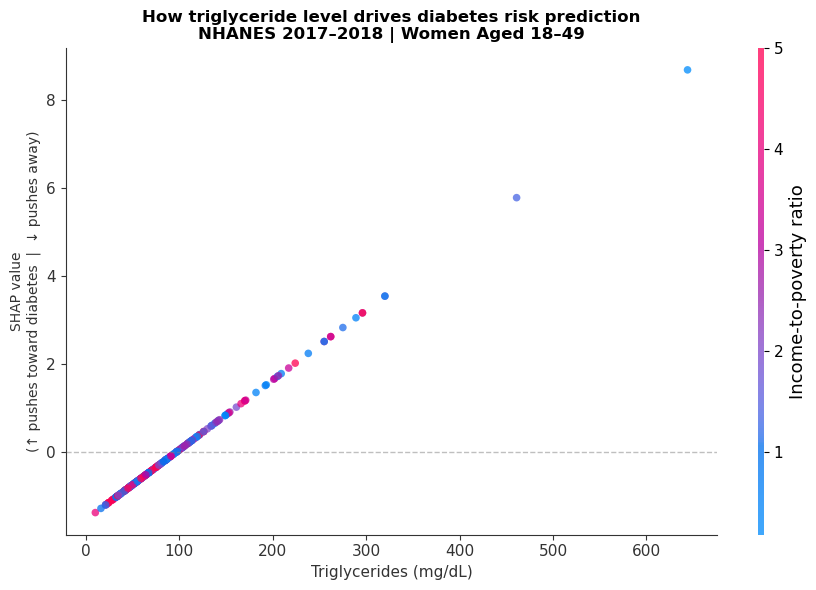

Saved: shap_dep_triglycerides_mgdl.png


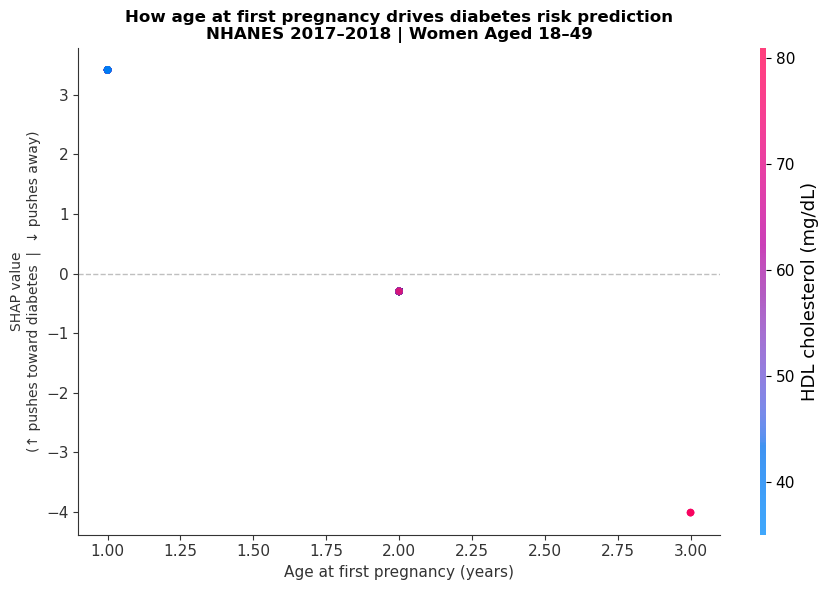

Saved: shap_dep_age_at_first_pregnancy.png


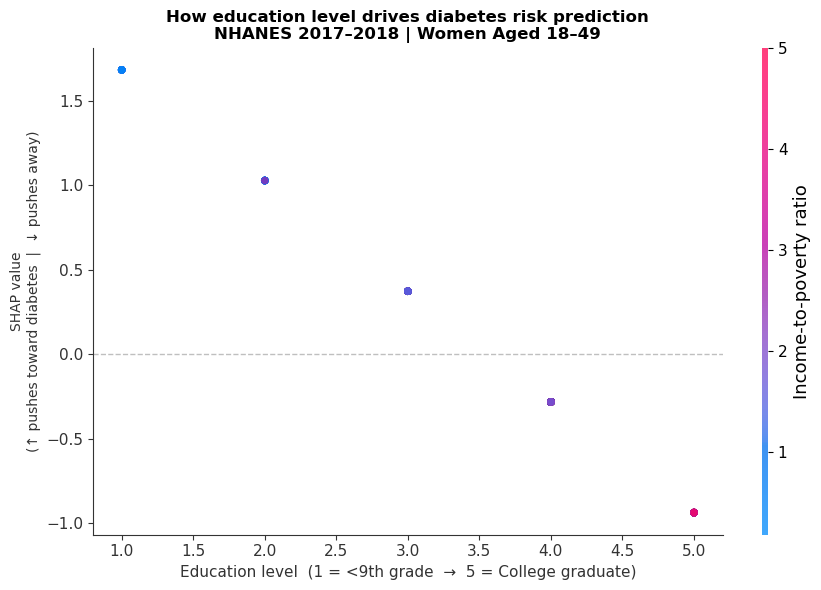

Saved: shap_dep_education_level.png


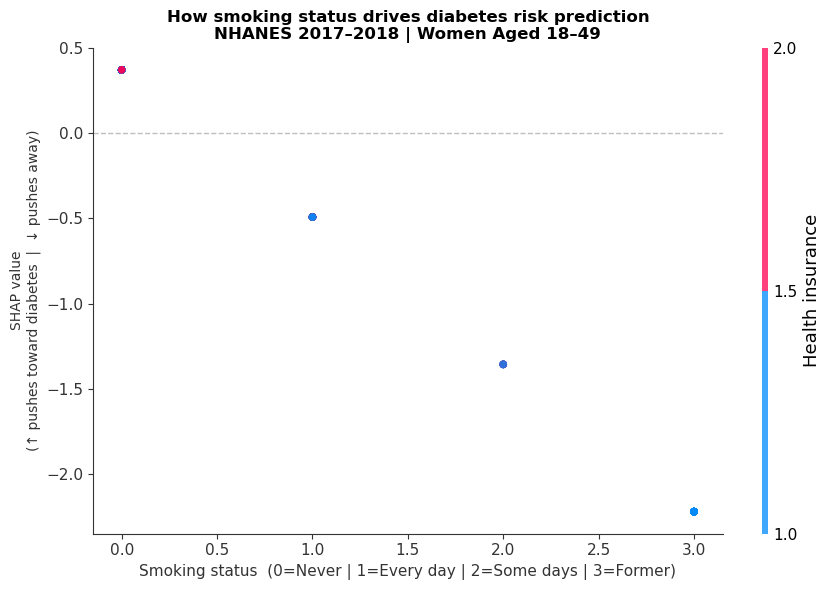

Saved: shap_dep_smoking_status.png


In [54]:
# --- SHAP dependence plots — top 5 features ----------------------------------

top_features = [
    ("Age (years)",
     "Age (years)",
     "How age drives diabetes risk prediction"),
    ("Triglycerides (mg/dL)",
     "Triglycerides (mg/dL)",
     "How triglyceride level drives diabetes risk prediction"),
    ("Age at first pregnancy",
     "Age at first pregnancy (years)",
     "How age at first pregnancy drives diabetes risk prediction"),
    ("Education level",
     "Education level  (1 = <9th grade  →  5 = College graduate)",
     "How education level drives diabetes risk prediction"),
    ("Smoking status",
     "Smoking status  (0=Never | 1=Every day | 2=Some days | 3=Former)",
     "How smoking status drives diabetes risk prediction")
]

# --- Combined panel ----------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, (ind_name, display_name, subtitle) in enumerate(top_features):
    shap.dependence_plot(
        ind         = ind_name,
        shap_values = shap_values,
        features    = X_test_original_labelled,
        ax          = axes[idx],
        show        = False,
        dot_size    = 25,
        alpha       = 0.75
    )
    axes[idx].set_title(subtitle, fontsize=11, fontweight="bold", pad=8)
    axes[idx].set_xlabel(display_name, fontsize=10)
    axes[idx].set_ylabel("SHAP value\n"
                          "(↑ pushes toward diabetes  |  ↓ pushes away)",
                          fontsize=9)
    axes[idx].spines["top"].set_visible(False)
    axes[idx].spines["right"].set_visible(False)
    axes[idx].axhline(y=0, linestyle="--", color="grey",
                      alpha=0.5, linewidth=0.8)

axes[5].set_visible(False)

plt.suptitle(
    "SHAP Dependence Plots: Top 5 Predictors\n"
    "Diabetes Risk Prediction | NHANES 2017–2018 | Women Aged 18–49",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("shap_dependence_top5_final.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: shap_dependence_top5_final.png")

# --- Individual plots --------------------------------------------------------
for ind_name, display_name, subtitle in top_features:
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.dependence_plot(
        ind         = ind_name,
        shap_values = shap_values,
        features    = X_test_original_labelled,
        ax          = ax,
        show        = False,
        dot_size    = 30,
        alpha       = 0.75
    )
    ax.set_title(f"{subtitle}\nNHANES 2017–2018 | Women Aged 18–49",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel(display_name, fontsize=11)
    ax.set_ylabel("SHAP value\n"
                  "(↑ pushes toward diabetes  |  ↓ pushes away)",
                  fontsize=10)
    ax.axhline(y=0, linestyle="--", color="grey", alpha=0.5, linewidth=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    safe = ind_name.lower().replace(" ", "_").replace(
           "/","").replace("(","").replace(")","")
    plt.tight_layout()
    plt.savefig(f"shap_dep_{safe}.png", dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: shap_dep_{safe}.png")

In [55]:
# --- Save SHAP importance with readable labels for Power BI -----------------

shap_importance = pd.DataFrame({
    "Feature":       list(X_test_original_labelled.columns),
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

print("SHAP feature importance ranking:\n")
print(shap_importance.to_string(index=False))

shap_importance.to_csv("shap_importance_labelled.csv", index=False)

# --- Save test predictions ---------------------------------------------------

test_predictions = pd.DataFrame({
    "true_label":    y_test.values,
    "pred_label":    preds["logistic_regression"],
    "pred_prob":     probas["logistic_regression"].round(4),
    "survey_weight": w_test.values
})

test_predictions.to_csv("test_predictions.csv", index=False)

print("\n--- All files saved for Power BI ---")
for f in ["model_comparison.csv",
          "performance_metrics.csv",
          "shap_importance_labelled.csv",
          "test_predictions.csv"]:
    print(f"  ✓ {f}")

print("\nPhase 10 complete.")

SHAP feature importance ranking:

                     Feature  Mean_Abs_SHAP
                 Age (years)       1.223790
       Triglycerides (mg/dL)       0.746855
      Age at first pregnancy       0.739151
             Education level       0.628608
              Smoking status       0.625146
     LDL cholesterol (mg/dL)       0.597413
            Health insurance       0.557878
     HDL cholesterol (mg/dL)       0.443968
       Alcohol use frequency       0.402653
Gestational diabetes history       0.357177
                 BMI (kg/m²)       0.302225
    Waist circumference (cm)       0.293843
       Number of pregnancies       0.279702
              Race/ethnicity       0.169205
     Income-to-poverty ratio       0.163886
       Sedentary minutes/day       0.144505
     Mean systolic BP (mmHg)       0.117761
    Mean diastolic BP (mmHg)       0.071173
           Heavy alcohol use       0.061876

--- All files saved for Power BI ---
  ✓ model_comparison.csv
  ✓ performance_metrics

In [56]:
# ============================================================
# Additional Power BI exports — Python
# ============================================================

# --- 1. ROC curve data for all 4 models -------------------------------------
# Power BI needs the actual FPR/TPR points to draw ROC curves natively

roc_data_list = []

for name in fitted_models:
    fpr, tpr, thresholds = roc_curve(y_test, probas[name])
    auc = roc_auc_score(y_test, probas[name])

    roc_df = pd.DataFrame({
        "Model":     display_names[name],
        "FPR":       fpr.round(4),
        "TPR":       tpr.round(4),
        "Threshold": thresholds.round(4) if len(thresholds) == len(fpr)
                     else np.append(thresholds, np.nan).round(4),
        "AUC":       round(auc, 3)
    })
    roc_data_list.append(roc_df)

roc_all = pd.concat(roc_data_list, ignore_index=True)
roc_all.to_csv("roc_curve_data.csv", index=False)
print(f"Saved: roc_curve_data.csv ({len(roc_all)} rows)")

# --- 2. Confusion matrix data -----------------------------------------------

cm = confusion_matrix(y_test, preds["logistic_regression"])
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame({
    "Actual":    ["No Diabetes", "No Diabetes", "Diabetes", "Diabetes"],
    "Predicted": ["No Diabetes", "Diabetes",    "No Diabetes", "Diabetes"],
    "Count":     [tn, fp, fn, tp],
    "Label":     ["True Negative", "False Positive",
                  "False Negative", "True Positive"]
})

cm_df.to_csv("confusion_matrix_data.csv", index=False)
print(f"Saved: confusion_matrix_data.csv")

# --- 3. SHAP dependence data for scatter plots ------------------------------
# Export the actual x and y values for each dependence plot

shap_dep_export = X_test_original_labelled.copy()
shap_dep_export["Survey_weight"] = w_test.values
shap_df = pd.DataFrame(
    shap_values,
    columns = [f"SHAP_{col}" for col in X_test_original_labelled.columns]
)

shap_full = pd.concat([shap_dep_export, shap_df], axis=1)
shap_full.to_csv("shap_dependence_data.csv", index=False)
print(f"Saved: shap_dependence_data.csv ({shap_full.shape})")

# --- 4. Model comparison with CV and test AUC side by side -----------------

cv_aucs = {
    "Logistic Regression": (0.885, 0.061),
    "Random Forest":       (0.872, 0.073),
    "XGBoost":             (0.853, 0.078),
    "LightGBM":            (0.834, 0.078)
}

model_full = pd.DataFrame({
    "Model":    list(display_names.values()),
    "CV_AUC":   [cv_aucs[n][0] for n in display_names.values()],
    "CV_SD":    [cv_aucs[n][1] for n in display_names.values()],
    "Test_AUC": [round(roc_auc_score(y_test, probas[n]), 3)
                 for n in fitted_models]
})

model_full.to_csv("model_comparison_full.csv", index=False)
print(f"Saved: model_comparison_full.csv")
print(model_full.to_string(index=False))

print("\n--- Complete Power BI file list ---")
all_files = [
    "prevalence_overall.csv",
    "prevalence_by_race.csv",
    "prevalence_by_bmi.csv",
    "prevalence_by_education.csv",
    "prevalence_by_smoking.csv",
    "prevalence_by_gdm.csv",
    "boxplot_data.csv",
    "table1_continuous.csv",
    "model_comparison_full.csv",
    "performance_metrics.csv",
    "roc_curve_data.csv",
    "confusion_matrix_data.csv",
    "shap_importance_labelled.csv",
    "shap_dependence_data.csv",
    "unadjusted_OR_results.csv",
    "adjusted_OR_results.csv"
]

for f in all_files:
    print(f"  ✓ {f}")

Saved: roc_curve_data.csv (143 rows)
Saved: confusion_matrix_data.csv
Saved: shap_dependence_data.csv ((279, 39))
Saved: model_comparison_full.csv
              Model  CV_AUC  CV_SD  Test_AUC
Logistic Regression   0.885  0.061     0.861
      Random Forest   0.872  0.073     0.889
            XGBoost   0.853  0.078     0.846
           LightGBM   0.834  0.078     0.811

--- Complete Power BI file list ---
  ✓ prevalence_overall.csv
  ✓ prevalence_by_race.csv
  ✓ prevalence_by_bmi.csv
  ✓ prevalence_by_education.csv
  ✓ prevalence_by_smoking.csv
  ✓ prevalence_by_gdm.csv
  ✓ boxplot_data.csv
  ✓ table1_continuous.csv
  ✓ model_comparison_full.csv
  ✓ performance_metrics.csv
  ✓ roc_curve_data.csv
  ✓ confusion_matrix_data.csv
  ✓ shap_importance_labelled.csv
  ✓ shap_dependence_data.csv
  ✓ unadjusted_OR_results.csv
  ✓ adjusted_OR_results.csv
